In [5]:
# Install required packages (safe to re-run — skips already installed)
!pip install -q transformers datasets evaluate rouge_score sacrebleu sentencepiece accelerate
!pip install -q sentence-transformers faiss-cpu
!pip install -q bert_score
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 76.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 75.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 91.6 MB/s eta 0:00:00:00:010:01


In [6]:
import os
import re
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
warnings.filterwarnings('ignore')

import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    GenerationConfig,
)
import evaluate
from sentence_transformers import SentenceTransformer
import faiss

# ── GPU check ──────────────────────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {device}")
if device == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU found — training will be very slow on CPU.")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [ ]:
# ── Model names ─────────────────────────────────────────────────────────────
BASE_MODEL  = 'google/flan-t5-base'
EMBED_MODEL = 'sentence-transformers/all-MiniLM-L6-v2'

# ── Tokenisation limits ─────────────────────────────────────────────────────
MAX_INPUT_LEN  = 256
MAX_TARGET_LEN = 128
MAX_RAG_INPUT  = 512

# ── Training hyperparameters ────────────────────────────────────────────────
TRAIN_EPOCHS  = 5
BATCH_SIZE    = 16

LEARNING_RATE = 1e-4

WEIGHT_DECAY  = 0.01
WARMUP_RATIO  = 0.05
MAX_GRAD_NORM = 1.0   


# gradient clipping — extra safety net against overflow
# 3e-4 (v1) worked for small (77M) but causes fp16 NaN on base (250M):
# larger model → larger activations → forward pass overflows fp16 on T4.
# 1e-4 is the standard safe ceiling for base-size T5 fine-tuning.

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Configuration loaded.")
print(f"  Base model   : {BASE_MODEL}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Max grad norm: {MAX_GRAD_NORM}")

Configuration loaded.
  Base model   : google/flan-t5-base
  Learning rate: 0.0001
  Max grad norm: 1.0


In [46]:
# ── Load raw datasets ───────────────────────────────────────────────────────
df_A = pd.read_csv('/kaggle/input/datasets/faizyah/agroqa/AgroQA Dataset.csv')
df_B = pd.read_csv('/kaggle/input/datasets/faizyah/fao-manual-qa/FAO_Manual_QA .csv')
df_C = pd.read_csv('/kaggle/input/datasets/faizyah/agriculture-qa-english-only/agriculture-qa-english-only.csv')

In [30]:
df_A['source'] = 'agroqa'
df_B['source'] = 'fao_manual'
df_C['source'] = 'q_a_english'

In [53]:
df_A[df_A.duplicated(keep=False)]

Loading ITables v2.7.3 from the internet... (need help?)


In [26]:
df_A[df_A.duplicated(keep=False)].sort_values(by=['question', 'answer'])

,crop,question,answer
951,maize,how can I store my maize,Store in good pico bags in a cool dry place ma...
1277,maize,how can I store my maize,Store in good pico bags in a cool dry place ma...


In [32]:
df_B[df_B.duplicated(keep=False)]

,crop,question,answer,source


In [27]:
df_B[df_B.duplicated(keep=False)].sort_values(by=['question', 'answer'])

,crop,question,answer


In [55]:
df_C[df_C.duplicated(keep=False)]

Loading ITables v2.7.3 from the internet... (need help?)


In [29]:
df_C[df_C.duplicated(keep=False)].sort_values(by=['question', 'answers'])

,unnamed: 0,question,answers


## Pre-processing 

In [9]:
def clean_text(text: str) -> str:
    """Normalise a single text string."""
    text = str(text).strip()
    text = re.sub(r'[\x00-\x1f\x7f-\x9f]', ' ', text)   # remove control chars
    text = re.sub(r'\s+', ' ', text)                      # collapse whitespace
    text = text.lower() #lowercase
    text = text.strip()
    return text

In [58]:
sample_text = df_A.iloc[0]['Question']
sample_text

'Apart from hand weeding, what other method used to weed maize'

In [59]:
sample_text_cleaned = str(sample_text).strip()

In [60]:
sample_text_cleaned = re.sub(r'[\x00-\x1f\x7f-\x9f]', ' ', sample_text_cleaned)
sample_text_cleaned

'Apart from hand weeding, what other method used to weed maize'

In [61]:
sample_text_cleaned = re.sub(r'\s+', ' ', sample_text_cleaned)
sample_text_cleaned

'Apart from hand weeding, what other method used to weed maize'

In [62]:
sample_text_cleaned = sample_text_cleaned.strip()
sample_text_cleaned

'Apart from hand weeding, what other method used to weed maize'

In [63]:
sample_text_cleaned = sample_text_cleaned.lower()
sample_text_cleaned

'apart from hand weeding, what other method used to weed maize'

In [64]:
pip install itables

Note: you may need to restart the kernel to use updated packages.


In [65]:
import itables

itables.init_notebook_mode()

In [66]:
for df in [df_A, df_B, df_C]:
    display(df.iloc[0])

Loading ITables v2.7.3 from the internet... (need help?)


Loading ITables v2.7.3 from the internet... (need help?)


Loading ITables v2.7.3 from the internet... (need help?)


In [34]:
def normalise_data(df):

    ## Rename columns
    rename_map = {
        'answers': 'answer',
        'questions': 'question'
    }

    df.columns = df.columns.str.lower().str.strip()

    df = df.rename(columns=rename_map)

    ## Data cleaning for each question and answer

    df['answer'] = df['answer'].apply(clean_text)
    df['question'] = df['question'].apply(clean_text)

    df = df[['question', 'answer', 'source']]
    
    return df

#dfs = [nomalise]

result = []
for df in [df_A, df_B, df_C]:
    df = normalise_data(df)
    result.append(df)
    
result = pd.concat(result)

In [47]:
result

,question,answer,source
0,"apart from hand weeding, what other method use...",machinery weeders are available,agroqa
1,"apart from insecticide, what other method used...",use resistant verities and increase on water a...,agroqa
2,apart from sun drying which other method used ...,use tarpaulins or cemented floor free from dust,agroqa
3,"apart from sun drying, what other method can i...",solar driers,agroqa
4,as a farmer when should i harvest beans.,when the beans pods are yellowish green or dry...,agroqa
...,...,...,...
22610,does cassava mosaic affect the cassava stems?,"yes, it makes them small and not good for plan...",q_a_english
22611,how does the pathogen of phoma rot spread?,the pathogen of phoma rot is seed-borne.,q_a_english
22612,does cassava have much sugar in it when testing?,"yes, but not as much as sugar cane",q_a_english
22613,can the chemical used for storing affect seed ...,"no, it does not affect germination",q_a_english


In [48]:
# Quality , select answer with certain length

def filter_quality_answers(df):
    df['len_answer'] = df['answer'].str.split().str.len()

    return df[df['len_answer'] > 3]

result = filter_quality_answers(result)

In [49]:
result

,question,answer,source,len_answer
0,"apart from hand weeding, what other method use...",machinery weeders are available,agroqa,4
1,"apart from insecticide, what other method used...",use resistant verities and increase on water a...,agroqa,11
2,apart from sun drying which other method used ...,use tarpaulins or cemented floor free from dust,agroqa,8
4,as a farmer when should i harvest beans.,when the beans pods are yellowish green or dry...,agroqa,10
5,as a farmer which method is good to prevent so...,farmers can terrace their gardens or mulch the...,agroqa,12
...,...,...,...,...
22609,cassava and maize which one makes you stronger...,cassava has more calories and maize has more p...,q_a_english,9
22610,does cassava mosaic affect the cassava stems?,"yes, it makes them small and not good for plan...",q_a_english,10
22611,how does the pathogen of phoma rot spread?,the pathogen of phoma rot is seed-borne.,q_a_english,7
22612,does cassava have much sugar in it when testing?,"yes, but not as much as sugar cane",q_a_english,8


In [50]:
df = result.copy()

In [51]:
df

,question,answer,source,len_answer
0,"apart from hand weeding, what other method use...",machinery weeders are available,agroqa,4
1,"apart from insecticide, what other method used...",use resistant verities and increase on water a...,agroqa,11
2,apart from sun drying which other method used ...,use tarpaulins or cemented floor free from dust,agroqa,8
4,as a farmer when should i harvest beans.,when the beans pods are yellowish green or dry...,agroqa,10
5,as a farmer which method is good to prevent so...,farmers can terrace their gardens or mulch the...,agroqa,12
...,...,...,...,...
22609,cassava and maize which one makes you stronger...,cassava has more calories and maize has more p...,q_a_english,9
22610,does cassava mosaic affect the cassava stems?,"yes, it makes them small and not good for plan...",q_a_english,10
22611,how does the pathogen of phoma rot spread?,the pathogen of phoma rot is seed-borne.,q_a_english,7
22612,does cassava have much sugar in it when testing?,"yes, but not as much as sugar cane",q_a_english,8


## Tokenisation

In [52]:
# ── Load FLAN-T5-base tokeniser ──────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
print(f"Tokeniser loaded  : {BASE_MODEL}")
print(f"Vocab size        : {tokenizer.vocab_size:,}")
print(f"Model max length  : {tokenizer.model_max_length}")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Tokeniser loaded  : google/flan-t5-base
Vocab size        : 32,100
Model max length  : 512


In [53]:
# Prepend task-specific instruction
def prepend_instruction(row :pd.Series):
    return f"answer farming question: {row['question']}"

df['input_text'] = df.apply(prepend_instruction, axis=1)

In [54]:
df.head(3)[['input_text', 'answer']]

,input_text,answer
0,answer farming question: apart from hand weedi...,machinery weeders are available
1,answer farming question: apart from insecticid...,use resistant verities and increase on water a...
2,answer farming question: apart from sun drying...,use tarpaulins or cemented floor free from dust


In [55]:
from sklearn.model_selection import train_test_split

df_train, df_temp = train_test_split(df, test_size=0.30, random_state=SEED)
df_val,   df_test = train_test_split(df_temp,     test_size=0.50, random_state=SEED)

print(f"Train : {len(df_train):,}  ({len(df_train)/len(df):.1%})")
print(f"Val   : {len(df_val):,}  ({len(df_val)/len(df):.1%})")
print(f"Test  : {len(df_test):,}  ({len(df_test)/len(df):.1%})")

Train : 14,613  (70.0%)
Val   : 3,132  (15.0%)
Test  : 3,132  (15.0%)


In [95]:
# ── Convert to HuggingFace Dataset ───────────────────────────────────────────
cols = ['input_text', 'answer']

hf_train = Dataset.from_pandas(df_train[cols].reset_index(drop=True))
hf_val   = Dataset.from_pandas(df_val[cols].reset_index(drop=True))
hf_test  = Dataset.from_pandas(df_test[cols].reset_index(drop=True))

dataset = DatasetDict({'train': hf_train, 'validation': hf_val, 'test': hf_test})
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['input_text', 'answer'],
        num_rows: 14613
    })
    validation: Dataset({
        features: ['input_text', 'answer'],
        num_rows: 3132
    })
    test: Dataset({
        features: ['input_text', 'answer'],
        num_rows: 3132
    })
})


In [96]:
# ── Tokenise ─────────────────────────────────────────────────────────────────

def tokenize_batch(examples):
    """
    Tokenise WITHOUT pre-padding.

    Do NOT use padding='max_length' here and do NOT manually replace pad
    tokens with -100.  When you pre-pad and then pass to DataCollatorForSeq2Seq,
    its internal _shift_right() builds decoder_input_ids from those labels —
    most positions are already -100, so _shift_right fills them with pad_token_id=0,
    giving the decoder an all-padding input → no real signal → loss = 0 and stuck.

    Letting DataCollatorForSeq2Seq own ALL padding means it:
      • pads each batch to its longest sequence (memory-efficient)
      • replaces label padding with -100 via label_pad_token_id
      • correctly builds decoder_input_ids from the real token sequences
    """
    model_inputs = tokenizer(
        examples['input_text'],
        max_length=MAX_INPUT_LEN,
        truncation=True,
    )
    labels = tokenizer(
        text_target=examples['answer'],
        max_length=MAX_TARGET_LEN,
        truncation=True,
    )
    model_inputs['labels'] = labels['input_ids']
    return model_inputs


tokenized = dataset.map(
    tokenize_batch,
    batched=True,
    batch_size=512,
    remove_columns=['input_text', 'answer'],
    desc='Tokenising'
)

print(tokenized)
print(f"\nSample (train[0]):")
print(f"  input len : {len(tokenized['train'][0]['input_ids'])} tokens (unpadded)")
print(f"  label len : {len(tokenized['train'][0]['labels'])} tokens (unpadded)")


Tokenising:   0%|          | 0/14613 [00:00<?, ? examples/s]

Tokenising:   0%|          | 0/3132 [00:00<?, ? examples/s]

Tokenising:   0%|          | 0/3132 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 14613
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 3132
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 3132
    })
})

Sample (train[0]):
  input len : 16 tokens (unpadded)
  label len : 8 tokens (unpadded)


In [97]:
tokenized

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 14613
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 3132
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 3132
    })
})

In [102]:
dataset['train'][0]

{'input_text': 'answer farming question: can i spray weeds in my bean garden',
 'answer': 'depends on what you are spraying'}

In [103]:
tokenized['train'][0]

{'input_ids': [1525,
  13293,
  822,
  10,
  54,
  3,
  23,
  5974,
  3,
  8578,
  7,
  16,
  82,
  15431,
  2004,
  1],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 'labels': [5619, 30, 125, 25, 33, 5974, 53, 1]}

In [104]:
print(tokenizer.decode(tokenized['train'][0]['input_ids']))

answer farming question: can i spray weeds in my bean garden</s>


In [105]:
print(tokenizer.decode(tokenized['train'][0]['labels']))

depends on what you are spraying</s>


In [106]:
print(tokenizer.decode(tokenized['train'][0]['attention_mask']))

</s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s>


In [107]:
# ── Load FLAN-T5-base ────────────────────────────────────────────────────────
model = AutoModelForSeq2SeqLM.from_pretrained(BASE_MODEL)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Total parameters     : 247,577,856
Trainable parameters : 247,577,856


In [108]:
# # ── Training arguments ───────────────────────────────────────────────────────

# # warmup_ratio is deprecated in Trainer v5 — compute steps explicitly
# _steps_per_epoch = len(tokenized['train']) // BATCH_SIZE
# _total_steps     = _steps_per_epoch * TRAIN_EPOCHS
# WARMUP_STEPS     = max(1, int(WARMUP_RATIO * _total_steps))
# print(f"Steps / epoch : {_steps_per_epoch}")
# print(f"Total steps   : {_total_steps}")
# print(f"Warmup steps  : {WARMUP_STEPS}  ({WARMUP_RATIO:.0%} of total)")



Steps / epoch : 913
Total steps   : 4565
Warmup steps  : 228  (5% of total)


In [120]:
# from evaluate import load
# import numpy as np

# bertscore_metric = load('bertscore')

# def compute_metrics(eval_preds):
#     preds, labels = eval_preds

#     if isinstance(preds, tuple):
#         preds = preds[0]
#     if preds.ndim == 3:
#         preds = np.argmax(preds, axis=-1)
#     preds = np.clip(preds, 0, tokenizer.vocab_size - 1).astype(np.int32)

#     decoded_preds  = tokenizer.batch_decode(preds, skip_special_tokens=True)
#     labels         = np.where(labels != -100, labels, tokenizer.pad_token_id)
#     decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

#     decoded_preds  = [p.strip() for p in decoded_preds]
#     decoded_labels = [l.strip() for l in decoded_labels]

#     bert_result = bertscore_metric.compute(
#         predictions=decoded_preds,
#         references=decoded_labels,
#         lang='en',
#         model_type='distilbert-base-uncased'
#     )

#     return {
#         'bertscore_p':  round(np.mean(bert_result['precision']), 4),
#         'bertscore_r':  round(np.mean(bert_result['recall']), 4),
#         'bertscore_f1': round(np.mean(bert_result['f1']), 4),
#     }

In [121]:
# OUTPUT_DIR = '/kaggle/working/'

# training_args = Seq2SeqTrainingArguments(
#     output_dir=OUTPUT_DIR,

#     # Training schedule
#     num_train_epochs=TRAIN_EPOCHS,
#     per_device_train_batch_size=BATCH_SIZE,
#     per_device_eval_batch_size=BATCH_SIZE,
#     learning_rate=LEARNING_RATE,
#     weight_decay=WEIGHT_DECAY,
#     warmup_steps=WARMUP_STEPS,
#     max_grad_norm=MAX_GRAD_NORM,

#     # Evaluation & checkpointing
#     eval_strategy='epoch',
#     save_strategy='epoch',
#     load_best_model_at_end=True,
#     metric_for_best_model='bertscore_f1',
#     greater_is_better=True,
#     save_total_limit=2,

#     # Generation settings for eval
#     predict_with_generate=True,
#     generation_max_length=MAX_TARGET_LEN,

#     # fp16=False — FLAN-T5-base attention activations overflow fp16 on T4
#     # (Turing arch, no bfloat16).  The forward pass itself produces NaN before
#     # gradients are even computed, so max_grad_norm cannot help.
#     # With ~3K training samples the extra wall-clock time is only ~3-4 minutes.
#     fp16=False,

#     dataloader_num_workers=2,
#     logging_steps=max(1, _steps_per_epoch // 4),  # ~4 logs per epoch
#     report_to='none',
#     seed=SEED,
# )

In [122]:
# data_collator = DataCollatorForSeq2Seq(
#     tokenizer=tokenizer,
#     model=model,
#     padding=True,
#     label_pad_token_id=-100,
#     pad_to_multiple_of=8,
# )

# print("\nTraining arguments set.")
# print("  fp16        : False  (disabled — prevents forward-pass NaN on T4)")
# print(f"  lr          : {LEARNING_RATE}")
# print(f"  grad clip   : {MAX_GRAD_NORM}")


Training arguments set.
  fp16        : False  (disabled — prevents forward-pass NaN on T4)
  lr          : 0.0001
  grad clip   : 1.0


In [123]:
# # ── Initialise Seq2SeqTrainer ────────────────────────────────────────────────
# trainer = Seq2SeqTrainer(
#     model=model,
#     args=training_args,
#     train_dataset=tokenized['train'],
#     eval_dataset=tokenized['validation'],
#     processing_class=tokenizer,
#     data_collator=data_collator,
#     compute_metrics=compute_metrics
# )

# print("Trainer initialised.")
# print(f"  Train batches / epoch : {len(tokenized['train']) // BATCH_SIZE:,}")
# print(f"  Total training steps  : {(len(tokenized['train']) // BATCH_SIZE) * TRAIN_EPOCHS:,}")

Trainer initialised.
  Train batches / epoch : 913
  Total training steps  : 4,565


In [124]:
# # ── Train ────────────────────────────────────────────────────────────────────
# print("Starting fine-tuning …")
# train_result = trainer.train()

# print("\nTraining complete.")
# print(f"  Total train runtime : {train_result.metrics['train_runtime']:.0f} s")
# print(f"  Train loss (final)  : {train_result.metrics['train_loss']:.4f}")

Starting fine-tuning …


Epoch,Training Loss,Validation Loss,Bertscore P,Bertscore R,Bertscore F1
1,6.757220,2.965620,0.770000,0.754700,0.761500
2,6.094925,2.608034,0.782900,0.761800,0.771500
3,5.666354,2.396728,0.791300,0.771200,0.780300
4,5.353341,2.269943,0.795300,0.773900,0.783700
5,5.168198,2.228243,0.796700,0.777600,0.786300


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].



Training complete.
  Total train runtime : 3356 s
  Train loss (final)  : 5.9485


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokeniser saved to: /kaggle/working/


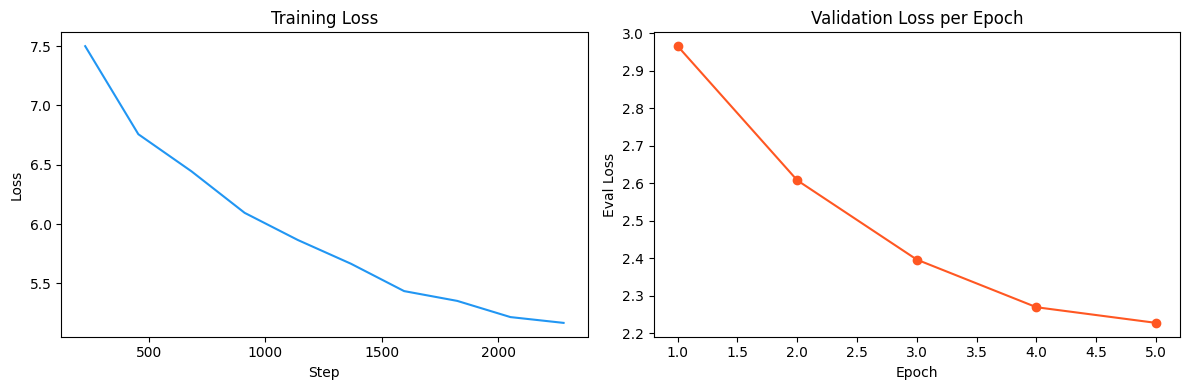

In [126]:
OUTPUT_DIR = '/kaggle/working/'


# ── Save best model & tokeniser ──────────────────────────────────────────────
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Model and tokeniser saved to: {OUTPUT_DIR}")

# Plot training loss if available
if hasattr(trainer.state, 'log_history') and trainer.state.log_history:
    train_logs = [l for l in trainer.state.log_history if 'loss' in l and 'eval_loss' not in l]
    eval_logs  = [l for l in trainer.state.log_history if 'eval_loss' in l]

    if train_logs and eval_logs:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].plot([l['step'] for l in train_logs], [l['loss'] for l in train_logs],
                     color='#2196F3', linewidth=1.5)
        axes[0].set_title('Training Loss', fontsize=12)
        axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss')

        axes[1].plot([l['epoch'] for l in eval_logs], [l['eval_loss'] for l in eval_logs],
                     color='#FF5722', marker='o', linewidth=1.5)
        axes[1].set_title('Validation Loss per Epoch', fontsize=12)
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Eval Loss')

        plt.tight_layout()
        plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
        plt.show()

In [132]:
# import shutil
# # Replace 'model_directory' with the folder holding your safetensors file
# shutil.make_archive('model.safetensors', 'zip', '/kaggle/working/')

In [131]:
# from IPython.display import FileLink
# # Generate a link for the file directly
# FileLink(r'model.safetensors')

/kaggle/working/model.safetensors

In [1]:
from huggingface_hub import login
login(token="xx")

In [143]:
# model.push_to_hub("fabienyah321/agribot-flan-t5")
# tokenizer.push_to_hub("fabienyah321/agribot-flan-t5")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/fabienyah321/agribot-flan-t5/commit/77737ffc38ffa08041f1089507fb13ec12f238bb', commit_message='Upload tokenizer', commit_description='', oid='77737ffc38ffa08041f1089507fb13ec12f238bb', pr_url=None, repo_url=RepoUrl('https://huggingface.co/fabienyah321/agribot-flan-t5', endpoint='https://huggingface.co', repo_type='model', repo_id='fabienyah321/agribot-flan-t5'), pr_revision=None, pr_num=None)

## Inference

In [2]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

model_path = "fabienyah321/agribot-flan-t5"  # <- just this changes

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSeq2SeqLM.from_pretrained(model_path)
model.eval()

def ask(question):
    prompt = f"answer farming question:{question.lower()}"
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=256)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=128,
            num_beams=4,
            early_stopping=True
        )
    
    return tokenizer.decode(outputs[0], skip_special_tokens=True)



config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/907 [00:00<?, ?B/s]

In [3]:
print(ask("How do I prevent root rot in rice?"))


infected plants can be prevented by using organic matter such as organic matter, such as organic matter, which can help to prevent root rot in beans.


In [148]:
print(ask("What is the best fertilizer for tomatoes?"))


a fertilizer with a nutrient level of 5.5 to 7.5. the best fertilizer for beans is a fertilizer with a nutrient levels of 5.5 to 5.5. the best fertilizer for beans is a fertilizer with a nutrient levels of 5.5 to 7.5.


In [149]:
print(ask("How often should I water my crops?"))

watering is important for plant growth and helps to improve soil fertility. watering is important for the growth and growth of crops, as it helps to improve soil fertility and improves soil fertility.


In [150]:
print(ask("As a farmer, How can I control pest"))

use pesticides and fungicides


In [154]:
print(ask("How can I conserve Soil"))

use organic matter: use organic matter to improve soil structure, improve soil fertility, and improve soil fertility.


In [155]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

base_model_path = "google/flan-t5-base"
finetuned_model_path = "fabienyah321/agribot-flan-t5"

finedtuned_tokenizer = AutoTokenizer.from_pretrained(finetuned_model_path)
finedtuned_model = AutoModelForSeq2SeqLM.from_pretrained(finetuned_model_path)
finedtuned_model.eval()

base_model_tokenizer = AutoTokenizer.from_pretrained(base_model_path)
base_model_model = AutoModelForSeq2SeqLM.from_pretrained(base_model_path)
base_model_model.eval()


def ask(question, model):
    prompt = f"answer farming question:{question.lower()}"
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=256)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=128,
            num_beams=4,
            early_stopping=True
        )
    
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [156]:
question = "As a farmer, How can I control pest"
print(f"Base model answer: {ask(question, base_model_model)}")
print(f"Finetuned model answer: {ask(question, finedtuned_model)}")

Base model answer: pesticides
Finetuned model answer: use pesticides and fungicides


In [158]:
question = "How can I know a bad quality growth in beans"
print(f"Base model answer: {ask(question, base_model_model)}")
print(f"Finetuned model answer: {ask(question, finedtuned_model)}")

Base model answer: if the beans are ripe
Finetuned model answer: the quality of beans can vary depending on various factors such as the variety of beans, soil fertility, and nutrient levels. however, if the quality of beans is low, it can lead to low yields, reduced yields, and reduced yields.


In [159]:
question = "How are you?"
print(f"Base model answer: {ask(question, base_model_model)}")
print(f"Finetuned model answer: {ask(question, finedtuned_model)}")

Base model answer: I'm fine
Finetuned model answer: a variety of plants are grown in a variety of conditions


In [160]:
question = "Prime minister of Malaysia?"
print(f"Base model answer: {ask(question, base_model_model)}")
print(f"Finetuned model answer: {ask(question, finedtuned_model)}")

Base model answer: Abdullah Mohamad
Finetuned model answer: it is based on a variety of factors such as soil fertility, crop rotation, and crop rotation.


In [162]:
question = "What is 1+1"
print(f"Base model answer: {ask(question, base_model_model)}")
print(f"Finetuned model answer: {ask(question, finedtuned_model)}")

Base model answer: +1
Finetuned model answer: is a variety of weeds and diseases that can cause a variety of pests and diseases


## RAG Pipeline

In [58]:
EMBED_MODEL = 'sentence-transformers/all-MiniLM-L6-v2'

# ── Load sentence-transformer embedding model ────────────────────────────────
embed_model = SentenceTransformer(EMBED_MODEL, device=device)
print(f"Embedding model loaded : {EMBED_MODEL}")
print(f"Embedding dimension    : {embed_model.get_sentence_embedding_dimension()}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded : sentence-transformers/all-MiniLM-L6-v2
Embedding dimension    : 384


In [164]:
df

Loading ITables v2.7.3 from the internet... (need help?)


In [56]:
df_train

,question,answer,source,len_answer,input_text
872,can i spray weeds in my bean garden,depends on what you are spraying,agroqa,6,answer farming question: can i spray weeds in ...
7120,what are the symptoms of cassava mosaic,"leaves leaves become distorted and yellow, poo...",q_a_english,25,answer farming question: what are the symptoms...
18161,what factors contribute to the spread of cmd.,viral infection: the disease is caused by the ...,q_a_english,77,answer farming question: what factors contribu...
11868,what irrigation techniques can farmers use to ...,drip or sprinkler irrigation,q_a_english,4,answer farming question: what irrigation techn...
21245,how does blockchain contribute to agriculture?,enhances transparency and traceability in the ...,q_a_english,11,answer farming question: how does blockchain c...
...,...,...,...,...,...
11079,is buying organic food better for the environm...,"ultimately, environmental sustainability comes...",q_a_english,15,answer farming question: is buying organic foo...
11929,what are the demerits of leaving maize stalks ...,disease and pest carryover: some diseases and ...,q_a_english,139,answer farming question: what are the demerits...
3834,how does clover cover crop enhanced songbird h...,"by providing cover and nesting sites, and an i...",q_a_english,15,answer farming question: how does clover cover...
1193,how can i maintain beans in the dry seasons?,by application of mulching,agroqa,4,answer farming question: how can i maintain be...


In [ ]:
/kaggle/working/

In [60]:
INDEX_PATH  = '/kaggle/working/agribot_faiss.index'
DOCS_PATH   = '/kaggle/working/agribot_docs.pkl'

In [61]:
# ── Build the knowledge base (from training data) ────────────────────────────

def build_knowledge_base(
    df: pd.DataFrame,
    embed_model: SentenceTransformer,
    index_path: str,
    docs_path: str,
    batch_size: int = 512,
):
    """
    Embed all QA pairs and store in a FAISS flat-IP index.
    Documents: list of dicts with keys text, question, answer, crop, source.
    Saves index and docs to disk so they can be reloaded without re-embedding.
    Returns (faiss_index, docs).
    """
    docs = [
        {
            'text'    : f"Q: {row['question']} A: {row['answer']}",
            'question': row['question'],
            'answer'  : row['answer']
        }
        for _, row in df.iterrows()
    ]

    texts = [d['text'] for d in docs]
    print(f"Embedding {len(texts):,} documents …")

    embeddings = embed_model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True,   # L2-normalise → cosine via IP
        convert_to_numpy=True,
    ).astype('float32')

    dim   = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(embeddings)

    # Persist to disk
    os.makedirs(os.path.dirname(index_path) or '.', exist_ok=True)
    faiss.write_index(index, index_path)
    with open(docs_path, 'wb') as f:
        pickle.dump(docs, f)

    print(f"FAISS index saved  : {index_path}")
    print(f"Docs list saved    : {docs_path}")
    print(f"Index size         : {index.ntotal:,} vectors  (dim={dim})")
    return index, docs


# Build from training split only — no test-set leakage
faiss_index, kb_docs = build_knowledge_base(
    df_train,
    embed_model,
    index_path=INDEX_PATH,
    docs_path=DOCS_PATH,
)

Embedding 14,613 documents …


Batches:   0%|          | 0/29 [00:00<?, ?it/s]

FAISS index saved  : /kaggle/working/agribot_faiss.index
Docs list saved    : /kaggle/working/agribot_docs.pkl
Index size         : 14,613 vectors  (dim=384)


In [62]:
# ── Helper: reload KB from disk (use after kernel restart) ──────────────────
def load_knowledge_base(index_path: str, docs_path: str):
    index = faiss.read_index(index_path)
    with open(docs_path, 'rb') as f:
        docs = pickle.load(f)
    print(f"Loaded FAISS index  : {index.ntotal:,} vectors")
    print(f"Loaded docs         : {len(docs):,} records")
    return index, docs

# Uncomment to reload without re-embedding:
# faiss_index, kb_docs = load_knowledge_base(INDEX_PATH, DOCS_PATH)

In [63]:
# ── Retrieval function ───────────────────────────────────────────────────────

def retrieve(
    question: str,
    faiss_index,
    docs: list,
    embed_model: SentenceTransformer,
    top_k: int = 3,
    threshold: float = 0.30,
) -> list:
    """
    Retrieve the top-k most similar documents above the cosine similarity threshold.
    Returns an empty list if no chunk meets the threshold (triggers guardrail layer 2).
    """
    query_emb = embed_model.encode(
        [question],
        normalize_embeddings=True,
        convert_to_numpy=True,
    ).astype('float32')

    scores, indices = faiss_index.search(query_emb, top_k)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx >= 0 and float(score) >= threshold:
            results.append({**docs[idx], 'score': float(score)})

    return results


# Quick sanity check
test_q   = "How do I control pests on cassava?"
test_res = retrieve(test_q, faiss_index, kb_docs, embed_model)
print(f"Query: {test_q!r}")
for i, r in enumerate(test_res, 1):
    print(f"  [{i}] score={r['score']:.3f} | {r['text'][:90]} …")

Query: 'How do I control pests on cassava?'
  [1] score=0.822 | Q: how can i control pest in cassava A: by spraying the garden with chemicals (pesticides) …
  [2] score=0.816 | Q: how can i control pests from my cassava garden A: use good crop management practices an …
  [3] score=0.802 | Q: how can i control pests and diseases in my cassava garden A: use resistant varieties or …


In [68]:
# Quick sanity check
test_q   = "For how long cassava takes to harvest?"
test_res = retrieve(test_q, faiss_index, kb_docs, embed_model)
display(f"Query: {test_q!r}")
for i, r in enumerate(test_res, 1):
    display(f"  [{i}] score={r['score']:.3f} | {r['text']} …")

"Query: 'For how long cassava takes to harvest?'"

'  [1] score=0.881 | Q: for how long cassava takes to harvest? A: for majority of varieties between 9 – 12 months …'

'  [2] score=0.795 | Q: what is the season for harvesting cassava A: harvest when it has reached physiological maturity at around 12 months …'

'  [3] score=0.786 | Q: when should i harvest my cassava A: when its mature at around 12 months …'

In [69]:
faiss_index

<faiss.swigfaiss_avx512.IndexFlatIP; proxy of <Swig Object of type 'faiss::IndexFlatIP *' at 0x7e173c195860> >

In [73]:
kb_docs[5]

{'text': 'Q: is agriculture a necessary industry? A: agriculture is a necessity!',
 'question': 'is agriculture a necessary industry?',
 'answer': 'agriculture is a necessity!'}

In [ ]:
# ── Prompt builder ───────────────────────────────────────────────────────────
def build_rag_prompt(question: str, chunks: list) -> str:
    """
    Assemble the RAG prompt injecting retrieved context.
    Prefix matches fine-tune format: 'answer farming question: <question>'
    Context is appended after the question to stay consistent with training distribution.
    """
    context_lines = [
        f"[{i+1}] Q: {c['question']} A: {c['answer']}"
        for i, c in enumerate(chunks)
    ]
    context = "\n".join(context_lines)
    return (
        f"answer farming question: {question}\n"
        f"Context:\n{context}"
    )


# ── Answer generator ─────────────────────────────────────────────────────────
def ask_rag(prompt: str, model, tokenizer, max_new_tokens: int = 128) -> str:
    """Run the fine-tuned FLAN-T5 on the RAG prompt."""
    inputs = tokenizer(
        prompt,
        return_tensors='pt',
        max_length=MAX_RAG_INPUT,
        truncation=True,
    ).to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            no_repeat_ngram_size=2,
            early_stopping=True,
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

In [88]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

out_of_box_path = "google/flan-t5-base"
finetuned_model_path = "fabienyah321/agribot-flan-t5"

finedtuned_tokenizer = AutoTokenizer.from_pretrained(finetuned_model_path)
finedtuned_model = AutoModelForSeq2SeqLM.from_pretrained(finetuned_model_path)
finedtuned_model.eval()

out_of_box_tokenizer = AutoTokenizer.from_pretrained(out_of_box_path)
out_of_box_model = AutoModelForSeq2SeqLM.from_pretrained(out_of_box_path)
out_of_box_model.eval()

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
              (wo):

In [95]:
def ask(question, model, tokenizer):
    prompt = f"answer farming question: {question.lower()}"
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=256)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=128,
            num_beams=4,
            early_stopping=True
        )
    
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# ── Answer generator ─────────────────────────────────────────────────────────
def ask_rag(prompt: str, model, tokenizer, max_new_tokens: int = 128) -> str:
    """Run the fine-tuned FLAN-T5 on the RAG prompt."""
    inputs = tokenizer(
        prompt,
        return_tensors='pt',
        max_length=MAX_RAG_INPUT,
        truncation=True,
    ).to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            no_repeat_ngram_size=2,
            early_stopping=True,
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

question = 'is agriculture a necessary industry?'


print(f"Question: {question}")
print("")

## out_of_box
print("Out-of-box")
print(f"NO RAG: {ask(question, out_of_box_model, out_of_box_tokenizer)}")
print(f"RAG: {ask_rag(question, out_of_box_model, out_of_box_tokenizer)}")

print()

## fine-tuned
print("Finetuned")
print(f"NO RAG: {ask(question, finedtuned_model, finedtuned_tokenizer)}")
print(f"RAG: {ask_rag(question, finedtuned_model, finedtuned_tokenizer)}")

Question: is agriculture a necessary industry?

Out-of-box
NO RAG: yes
RAG: yes

Finetuned
NO RAG: agriculture is a important industry in the growth and growth of a variety of crops.
RAG: crop rotation: farming is a important industry that can help to improve soil fertility, reduce erosion, and reduce pest and disease damage.


In [97]:
question = 'How are you?'

print(f"Question: {question}")
print("")

## out_of_box
print("Out-of-box")
print(f"NO RAG: {ask(question, out_of_box_model, out_of_box_tokenizer)}")
print(f"RAG: {ask_rag(question, out_of_box_model, out_of_box_tokenizer)}")

print()

## fine-tuned
print("Finetuned")
print(f"NO RAG: {ask(question, finedtuned_model, finedtuned_tokenizer)}")
print(f"RAG: {ask_rag(question, finedtuned_model, finedtuned_tokenizer)}")

Question: How are you?

Out-of-box
NO RAG: good
RAG: How are you?

Finetuned
NO RAG: a variety of plants are grown in a variety of conditions, such as water, soil, and water
RAG: it's a rainy season.


In [98]:
question = 'Prime Minister of Malaysia?'

print(f"Question: {question}")
print("")

## out_of_box
print("Out-of-box")
print(f"NO RAG: {ask(question, out_of_box_model, out_of_box_tokenizer)}")
print(f"RAG: {ask_rag(question, out_of_box_model, out_of_box_tokenizer)}")

print()

## fine-tuned
print("Finetuned")
print(f"NO RAG: {ask(question, finedtuned_model, finedtuned_tokenizer)}")
print(f"RAG: {ask_rag(question, finedtuned_model, finedtuned_tokenizer)}")

Question: Prime Minister of Malaysia?

Out-of-box
NO RAG: Abdullah Ghulam
RAG: Jaap Mohamad Abdullah Ghulam

Finetuned
NO RAG: it is based on a variety of factors such as soil fertility, crop rotation, and crop rotation.
RAG: italy


## Guardrail

In [99]:
# ── Layer 1: Intent / domain guardrail ───────────────────────────────────────

FARMING_KEYWORDS = {
    # Crops
    'crop', 'crops', 'cassava', 'maize', 'corn', 'beans', 'rice', 'wheat',
    'sorghum', 'millet', 'soybean', 'groundnut', 'peanut', 'potato', 'tomato',
    'vegetable', 'vegetables', 'fruit', 'fruits', 'orchard', 'cocoa', 'coffee',
    # Soil & inputs
    'soil', 'fertilizer', 'fertiliser', 'compost', 'manure', 'nitrogen',
    'phosphorus', 'potassium', 'pH', 'mulch', 'organic', 'amendment',
    # Pest & disease
    'pest', 'pests', 'disease', 'fungus', 'blight', 'aphid', 'worm', 'weevil',
    'pesticide', 'herbicide', 'fungicide', 'insecticide', 'spray', 'resistant',
    # Practices
    'farm', 'farming', 'agriculture', 'agronomy', 'plant', 'planting', 'seed',
    'seeds', 'germinate', 'germination', 'harvest', 'harvesting', 'weed',
    'weeding', 'irrigate', 'irrigation', 'water', 'drainage', 'spacing',
    'pruning', 'thinning', 'transplant', 'nursery', 'seedling', 'rotation',
    'intercrop', 'agroforestry', 'greenhouse', 'yield', 'produce',
    # Livestock
    'livestock', 'cattle', 'cow', 'poultry', 'chicken', 'goat', 'pig',
    # Land
    'field', 'plot', 'acre', 'hectare', 'land', 'ridge', 'furrow',
    # Context
    'farmer', 'farmer\'s', 'grow', 'growing', 'extension', 'season',
    'rainfall', 'drought', 'climate', 'weather',
}


def is_farming_related(question: str, min_matches: int = 1) -> bool:
    """
    Layer 1 guardrail: check whether the question overlaps with the
    agricultural vocabulary.  A single keyword match is sufficient.
    """
    tokens = set(re.sub(r"[^\w\s]", "", question.lower()).split())
    return len(tokens & FARMING_KEYWORDS) >= min_matches


# Smoke test
test_cases = [
    ("How do I control aphids on my maize?", True),
    ("What is the capital of France?",       False),
    ("When should I harvest cassava?",        True),
    ("How do I write a Python script?",       False),
    ("Best fertilizer for tomato plants?",    True),
]
print("Intent guardrail smoke test:")
for q, expected in test_cases:
    result = is_farming_related(q)
    status = '✓' if result == expected else '✗'
    print(f"  {status}  {result!s:5}  | {q}")

Intent guardrail smoke test:
  ✓  True   | How do I control aphids on my maize?
  ✓  False  | What is the capital of France?
  ✓  True   | When should I harvest cassava?
  ✓  False  | How do I write a Python script?
  ✓  True   | Best fertilizer for tomato plants?


In [108]:
import re

def is_valid_response(text: str, min_real_words: int = 3) -> bool:
    """
    Reject responses that are mostly gibberish.
    A 'real word' here means >= 3 chars and only standard characters.
    """
    words = text.split()
    real_words = [w for w in words if re.match(r'^[a-zA-Z]{3,}$', w)]
    return len(real_words) >= min_real_words

def ask_guardrail_rag(question, model, tokenizer, faiss_index, docs, embed_model,
                top_k=3, threshold=0.30, verbose=False):

    if not is_farming_related(question):
        return "I'm AgriBot! I specialise in farming and agriculture. ..."
    
    chunks = retrieve(question, faiss_index, docs, embed_model, top_k=top_k, threshold=threshold)

    if not chunks:
        return "I don't have enough information about that in my knowledge base. ..."

    prompt = build_rag_prompt(question, chunks)
    answer = generate_answer(prompt, model, tokenizer)

    # ── Layer 3: Output sanity check ─────────────────────────────────────────
    if not is_valid_response(answer):
        # Fall back to the best retrieved chunk instead
        return f"Based on my knowledge base: {chunks[0]['text']}"

    return answer

def ask_guardrail_no_rag(question, model, tokenizer,):

    if not is_farming_related(question):
        return "I'm AgriBot! I specialise in farming and agriculture. ..."

    answer = ask(question, model, tokenizer)

    # ── Layer 3: Output sanity check ─────────────────────────────────────────
    if not is_valid_response(answer):
        # Fall back to the best retrieved chunk instead
        return f"Not in my knowledge base."

    return answer

In [110]:
question = 'is agriculture a necessary industry?'


print(f"Question: {question}")
print("")

## out_of_box
print("Out-of-box")
print(f"NO RAG - NO GUARDRAIL: {ask(question, out_of_box_model, out_of_box_tokenizer)}")
print(f"RAG - NO GUARDRAIL: {ask_rag(question, out_of_box_model, out_of_box_tokenizer)}")
print(f"RAG -  GUARDRAIL: {ask_guardrail_rag(question, out_of_box_model, out_of_box_tokenizer,faiss_index, kb_docs, embed_model)}")
print(f"NO RAG -  GUARDRAIL: {ask_guardrail_no_rag(question, out_of_box_model, out_of_box_tokenizer)}")

print()

## fine-tuned
print("Finetuned")
print(f"NO RAG: {ask(question, finedtuned_model, finedtuned_tokenizer)}")
print(f"RAG: {ask_rag(question, finedtuned_model, finedtuned_tokenizer)}")
print(f"RAG -  GUARDRAIL: {ask_guardrail_rag(question, finedtuned_model, finedtuned_tokenizer,faiss_index, kb_docs, embed_model)}")
print(f"NO RAG -  GUARDRAIL: {ask_guardrail_no_rag(question, finedtuned_model, finedtuned_tokenizer)}")

Question: is agriculture a necessary industry?

Out-of-box
NO RAG - NO GUARDRAIL: yes
RAG - NO GUARDRAIL: yes
RAG -  GUARDRAIL: Based on my knowledge base: Q: is agriculture a necessary industry? A: agriculture is a necessity!
NO RAG -  GUARDRAIL: Not in my knowledge base.

Finetuned
NO RAG: agriculture is a important industry in the growth and growth of a variety of crops.
RAG: crop rotation: farming is a important industry that can help to improve soil fertility, reduce erosion, and reduce pest and disease damage.
RAG -  GUARDRAIL: agriculture is a necessary industry, as it helps to improve soil fertility, reduce erosion, and reduces damage to plants.
NO RAG -  GUARDRAIL: agriculture is a important industry in the growth and growth of a variety of crops.


In [111]:
question = 'how are you?'


print(f"Question: {question}")
print("")

## out_of_box
print("Out-of-box")
print(f"NO RAG - NO GUARDRAIL: {ask(question, out_of_box_model, out_of_box_tokenizer)}")
print(f"RAG - NO GUARDRAIL: {ask_rag(question, out_of_box_model, out_of_box_tokenizer)}")
print(f"RAG -  GUARDRAIL: {ask_guardrail_rag(question, out_of_box_model, out_of_box_tokenizer,faiss_index, kb_docs, embed_model)}")
print(f"NO RAG -  GUARDRAIL: {ask_guardrail_no_rag(question, out_of_box_model, out_of_box_tokenizer)}")

print()

## fine-tuned
print("Finetuned")
print(f"NO RAG: {ask(question, finedtuned_model, finedtuned_tokenizer)}")
print(f"RAG: {ask_rag(question, finedtuned_model, finedtuned_tokenizer)}")
print(f"RAG -  GUARDRAIL: {ask_guardrail_rag(question, finedtuned_model, finedtuned_tokenizer,faiss_index, kb_docs, embed_model)}")
print(f"NO RAG -  GUARDRAIL: {ask_guardrail_no_rag(question, finedtuned_model, finedtuned_tokenizer)}")

Question: how are you?

Out-of-box
NO RAG - NO GUARDRAIL: good
RAG - NO GUARDRAIL: how are you?
RAG -  GUARDRAIL: I'm AgriBot! I specialise in farming and agriculture. ...
NO RAG -  GUARDRAIL: I'm AgriBot! I specialise in farming and agriculture. ...

Finetuned
NO RAG: a variety of plants are grown in a variety of conditions, such as water, soil, and water
RAG: it is raining
RAG -  GUARDRAIL: I'm AgriBot! I specialise in farming and agriculture. ...
NO RAG -  GUARDRAIL: I'm AgriBot! I specialise in farming and agriculture. ...
